# ThousandWorlds quickstart


In [1]:
from pathlib import Path
import pandas as pd
import thousandworlds as tw
from thousandworlds.models.train_mean import TrainMean



Download the dataset archive into the repository. (The checkout already has metadata; this fills in the large array files.)


In [2]:
tw.download_dataset()

Dataset already present at `/mnt/home/estevenson/XCE/thousandworlds/dataset/`, skipping download.


PosixPath('/mnt/home/estevenson/XCE/thousandworlds/dataset')

Load the `single-complete` benchmark subset.


In [3]:
data_dir = Path("dataset")
bundle = tw.load("single-complete", data_dir=data_dir)
stats = tw.load_stats("single-complete", data_dir)
bundle.X_train.shape, bundle.Y_train.shape, bundle.Y_test.shape


((203, 8), (203, 48, 32, 64), (74, 48, 32, 64))

Check which output fields are present in the test set.


In [4]:
pd.DataFrame({
    "field": bundle.field_names,
    "observed_in_test": bundle.field_mask_test.mean(axis=0),
}).head()


,field,observed_in_test
0,surface_temperature,1.0
1,temperature_0,1.0
2,temperature_1,1.0
3,temperature_2,1.0
4,temperature_3,1.0


Fit the train-mean baseline and predict the held-out simulations.


In [5]:
model = TrainMean().fit(
    bundle.Y_train,
    bundle.raw_field_names,
    stats,
    X_train=bundle.X_train,
    field_mask=bundle.field_mask_train,
)
pred = model.predict(bundle.X_test)


Visualise a prediction: e.g., here is the surface temperature for one held-out world. It can be useful to view the target, the prediction, and their residual together for seeing where a model struggles.

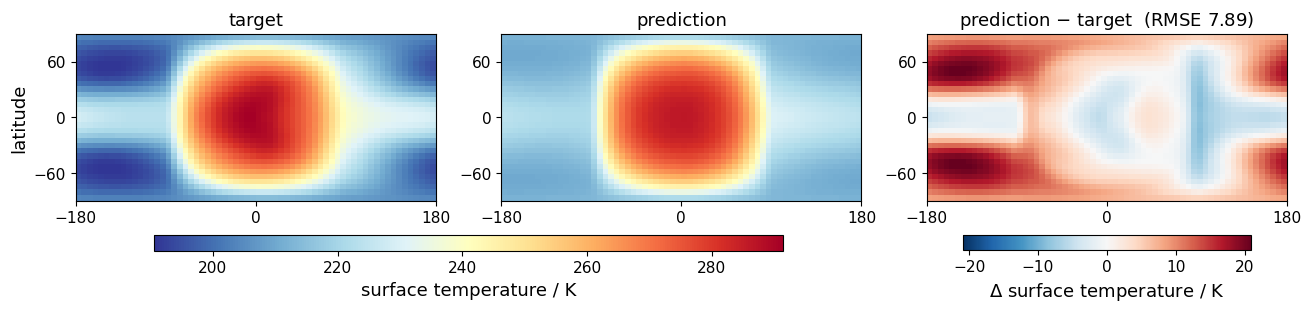

In [6]:
fig, _ = tw.viz.compare_field(bundle, pred, field="surface_temperature", idx=1)

Score the predictions and display RMSE by physical variable.


In [7]:
scores = tw.score_predictions(pred, bundle)
pd.Series(scores["rmse"]["per_variable"], name="rmse")


surface_temperature      20.850534
temperature              18.707745
specific_humidity_dex     1.066843
cloud_fraction            0.128749
u                        12.750722
v                         5.162652
asr                      45.581081
olr                      33.693996
Name: rmse, dtype: float64